Loading main data from: logs\ytmusic\reddit_2025-new_ytmusic_scored_new_matches.tsv_2025-12-14.tsv
Main TSV loaded successfully. Shape: (9411, 23)

Setting initial 'manual_label' based on 'match_quality'...
Initial label counts:
manual_label
0.0    1683
0.5     996
1.0    6732
Name: count, dtype: int64

Loading overrides from: logs\ytmusic\reddit_2025_gemini_match_overrides.tsv
Applying 5207 overrides...

--- Final Label Statistics After Applying Overrides ---
manual_label
0.0    2899
0.5      49
1.0    6463
Name: count, dtype: int64

Generating comparison plots...


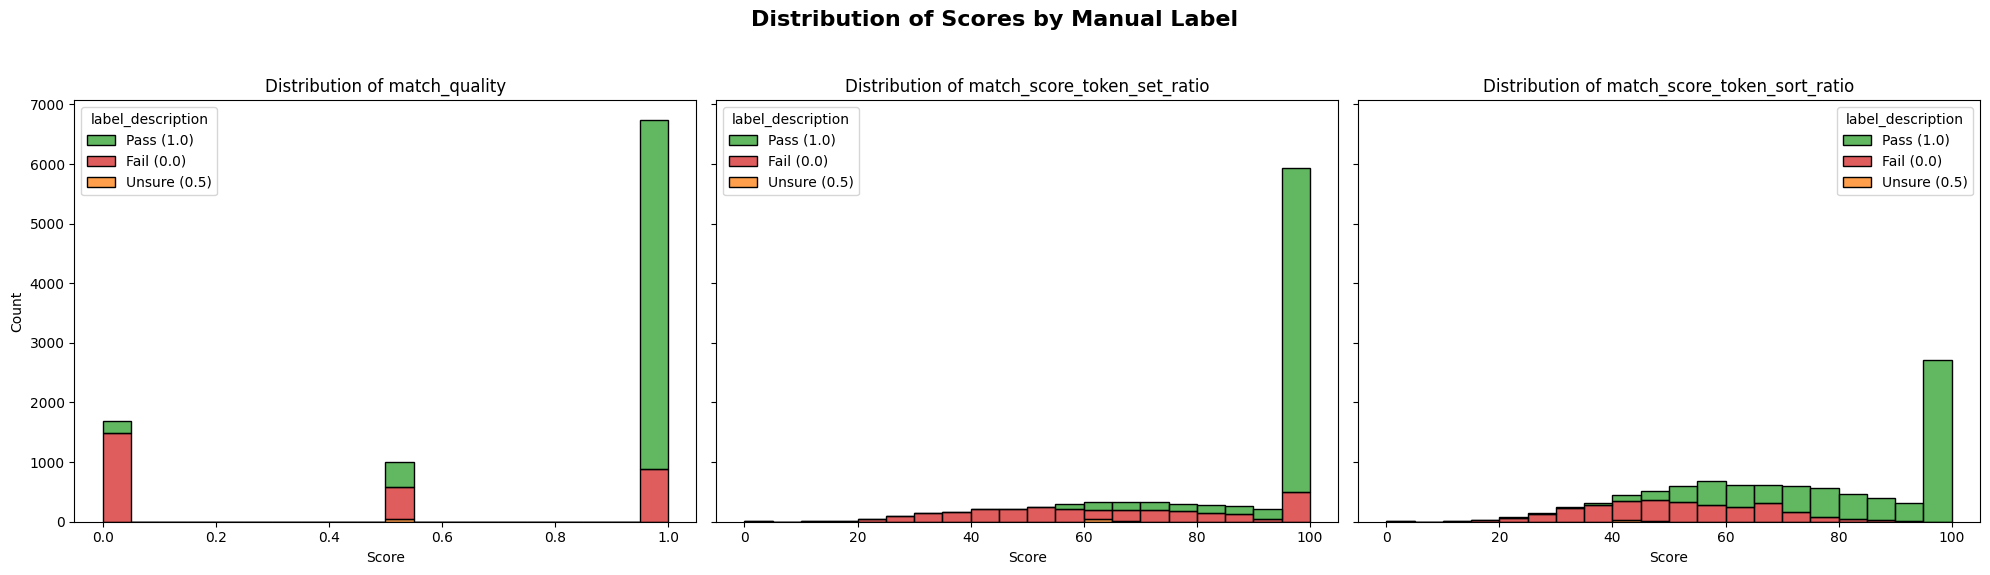

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Define File Paths ---
# Using os.path.join for cross-platform compatibility
log_dir = os.path.join('logs', 'ytmusic')
main_file_path = os.path.join(log_dir, 'reddit_2025-new_ytmusic_scored_new_matches.tsv_2025-12-14.tsv')
override_file_path = os.path.join(log_dir, 'reddit_2025_gemini_match_overrides.tsv')

# --- 2. Load the Main TSV File ---
print(f"Loading main data from: {main_file_path}")
df = pd.read_csv(
    main_file_path,
    sep='\t',        # Tab-separated file
    index_col=0      # Use the first column as the DataFrame index
)
print(f"Main TSV loaded successfully. Shape: {df.shape}")

# --- 3. Set Initial Labels Based on 'match_quality' ---
print("\nSetting initial 'manual_label' based on 'match_quality'...")
df['manual_label'] = df['match_quality']
print("Initial label counts:")
print(df['manual_label'].value_counts().sort_index())

# --- 4. Load and Apply Overrides ---
print(f"\nLoading overrides from: {override_file_path}")
df_overrides = pd.read_csv(
    override_file_path,
    sep='\t',
    index_col='index' # Use the 'index' column from the TSV as the index
)

print(f"Applying {len(df_overrides)} overrides...")
# Update aligns on the index and modifies the 'df' DataFrame in-place
df.update(df_overrides)

# --- 5. Print Final Statistics ---
print("\n--- Final Label Statistics After Applying Overrides ---")
print(df['manual_label'].value_counts().sort_index())

# --- 6. Visualize the Results ---
print("\nGenerating comparison plots...")

# For clearer plot legends, map the numeric labels to descriptive strings
df['label_description'] = df['manual_label'].map({
    1.0: 'Pass (1.0)',
    0.5: 'Unsure (0.5)',
    0.0: 'Fail (0.0)'
}).fillna('Other')

# Define the score columns to plot
score_columns = [
    'match_quality',
    'match_score_token_set_ratio',
    'match_score_token_sort_ratio'
]

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, len(score_columns), figsize=(20, 6), sharey=True)
fig.suptitle('Distribution of Scores by Manual Label', fontsize=16, weight='bold')

# Define a color palette for consistency
palette = {
    'Pass (1.0)': '#2ca02c',  # Green
    'Unsure (0.5)': '#ff7f0e', # Orange
    'Fail (0.0)': '#d62728'   # Red
}

# Generate a histogram for each score column
for i, col in enumerate(score_columns):
    sns.histplot(
        data=df,
        x=col,
        hue='label_description', # Color bars based on the label
        multiple='stack',        # Stack bars for each category
        palette=palette,
        ax=axes[i],
        bins=20                  # Use 20 bins for the histogram
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Score')
    if i == 0:
        axes[i].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

In [ ]:
# --- Display "Unsure" Matches for Review ---

# This cell filters the main DataFrame to show only the rows that are 
# still marked as 'Unsure' (0.5). We select a subset of essential 
# columns to make manual review easier.

# Define the columns that are most useful for comparing the match
essential_cols = [
    'manual_label',
    'reddit_title',
    'ytmusic_title',
    'ytmusic_artist',
    'match_quality',
    'match_score_token_set_ratio',
    'match_score_token_sort_ratio',
    'ytmusic_key',
    'reddit_key'
]

# Filter the DataFrame for rows where manual_label is 0.5
df_unsure = df.loc[df['manual_label'] == 0.5, essential_cols]

print(f"Found {len(df_unsure)} items still marked as 'Unsure' (0.5) for review.")

# Display the resulting DxataFrame in the notebook
# The last line of a cell being a variable will automatically render it.
print(df_unsure.to_csv())

Found 49 items still marked as 'Unsure' (0.5) for review.
,manual_label,reddit_title,ytmusic_title,ytmusic_artist,match_quality,match_score_token_set_ratio,match_score_token_sort_ratio,ytmusic_key,reddit_key
56,0.5,Messing Around,Messin' Around (feat. Enrique Iglesias),Pitbull,0.5,60.0,46.0,pitbull - messin' around (feat. enrique iglesias),messing around
429,0.5,"Farley Jackmaster Funk Presents Precious Red - Think. 12"" Vinyl 1989",Precious Red,The Portraits,0.5,63.0,42.0,the portraits - precious red,"farley jackmaster funk presents precious red - think. 12"" vinyl 1989"
544,0.5,Orchestre Poly-Rythmo de Cotonou - Djanfa Magni,Djanfa Magni,Tidiani Koné,0.5,67.0,41.0,tidiani koné - djanfa magni,orchestre poly-rythmo de cotonou - djanfa magni
875,0.5,My first soundtrack cover! | Mushi-shi - From Beyond the Sea,Beyond the Sea,Robbie Williams,0.5,64.0,42.0,robbie williams - beyond the sea,my first soundtrack cover! (mushi-shi - from beyond the sea
957,0.5,"Blu Mar Ten - Adrift On Deep Wate

In [24]:
import pandas as pd
import os

# --- 1. Setup: Define File Paths and Manual Labels ---
print("--- Step 1: Initializing Setup ---")

# Define the directory and file paths
log_dir = os.path.join('logs', 'ytmusic')
new_data_path = os.path.join(log_dir, 'reddit_2025-new_ytmusic_scored_new_matches.tsv_2025-12-14.tsv')
overrides_path = os.path.join(log_dir, 'reddit_2025_gemini_match_overrides.tsv')
master_path = os.path.join(log_dir, 'reddit_2024-new_ytmusic_scored_new_matches__model-graded_2024-1-5.tsv')

# Hardcoded manual labels for the 49 "unsure" items, in the correct order
manual_review_labels = [
    1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
    1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
    1, 0, 0, 0, 1, 1, 0, 0, 0
]

# Define the sorting order for output files
sort_columns = ['reddit_sub', 'manual_label', 'match_score_token_set_ratio']
sort_order = [True, True, False] # Ascending for sub/label, Descending for score

# Define output file names
output_2025_filename = 'reddit_2025-new_ytmusic_scored_new_matches__gemini-graded_2025-12-13.tsv'
output_merged_filename = 'reddit_2024-2025-ytmusic_scored_matches__model-gemini-graded_2025-12-13.tsv'
output_2025_path = os.path.join(log_dir, output_2025_filename)
output_merged_path = os.path.join(log_dir, output_merged_filename)


# --- 2. Process the 2025 Data ---
print("\n--- Step 2: Loading and Processing 2025 Data ---")

# Load the main 2025 data
df_2025 = pd.read_csv(new_data_path, sep='\t', index_col=0)
print(f"Loaded {len(df_2025)} rows from 2025 data file.")

# Set initial labels from match_quality
df_2025['manual_label'] = df_2025['match_quality']

# Load and apply overrides
df_overrides = pd.read_csv(overrides_path, sep='\t', index_col='index')
df_2025.update(df_overrides)
print(f"Applied {len(df_overrides)} overrides.")

# Resolve the remaining "unsure" (0.5) labels
unsure_indices = df_2025[df_2025['manual_label'] == 0.5].index
if len(unsure_indices) == len(manual_review_labels):
    df_2025.loc[unsure_indices, 'manual_label'] = manual_review_labels
    print(f"Resolved {len(unsure_indices)} 'unsure' items with manual review labels.")
else:
    print(f"WARNING: Found {len(unsure_indices)} 'unsure' items, but have {len(manual_review_labels)} labels. Aborting.")
    exit()


# --- 3. Load Master Data and Prepare for Merge ---
print("\n--- Step 3: Loading Master Data and Preparing for Merge ---")

# Load the 2024 master data
df_master = pd.read_csv(master_path, sep='\t', index_col=0)
print(f"Loaded {len(df_master)} rows from master data file.")

# Add 'match_year' column to both DataFrames
df_master['match_year'] = 2024
df_2025['match_year'] = 2025
print("Added 'match_year' column to both datasets.")

# Harmonize the 'manual_label' column in the 2025 data to match the master format
label_map = {1.0: 'pass', 0.0: 'fail'}
df_2025['manual_label'] = df_2025['manual_label'].map(label_map)
print("Harmonized 'manual_label' in 2025 data to 'pass'/'fail' format.")


# --- 4. Sort and Save the Standalone 2025 File ---
print(f"\n--- Step 4: Saving Standalone 2025 Data ---")
df_2025_sorted = df_2025.sort_values(by=sort_columns, ascending=sort_order)
# We use index=False to prevent writing the old index as an unnamed column
df_2025_sorted.to_csv(output_2025_path, sep='\t', index=True)
print(f"✅ Successfully saved {len(df_2025_sorted)} rows to: {output_2025_path}")


# --- 5. Merge, De-duplicate, and Sort the Combined DataFrame ---
print("\n--- Step 5: Combining, Cleaning, and Sorting All Data ---")

# a) Concatenate the master and new data
df_merged = pd.concat([df_master, df_2025], ignore_index=True)
print(f"Merged DataFrame created with {len(df_merged)} total rows.")

# b) De-duplicate intelligently by keeping the entry with the highest score
duplicate_subset = ['ytmusic_key', 'reddit_key', 'reddit_sub']
df_merged.sort_values('match_score_token_set_ratio', ascending=False, inplace=True)
df_final = df_merged.drop_duplicates(subset=duplicate_subset, keep='first')
rows_removed = len(df_merged) - len(df_final)
print(f"Removed {rows_removed} duplicate rows, keeping the entry with the highest match score for each group.")

# c) Apply the final sorting order
df_final.sort_values(by=sort_columns, ascending=sort_order, inplace=True)
print("Final DataFrame has been sorted.")


# --- 6. Save the Final Combined File ---
print(f"\n--- Step 6: Saving Final Combined Data ---")
# Again, use index=False to ensure all columns are saved cleanly
df_final.to_csv(output_merged_path, sep='\t', index=True)
print(f"✅ Successfully saved {len(df_final)} rows to: {output_merged_path}")
print("\nProcess complete.")

--- Step 1: Initializing Setup ---

--- Step 2: Loading and Processing 2025 Data ---
Loaded 9411 rows from 2025 data file.
Applied 5207 overrides.
Resolved 49 'unsure' items with manual review labels.

--- Step 3: Loading Master Data and Preparing for Merge ---
Loaded 15042 rows from master data file.
Added 'match_year' column to both datasets.
Harmonized 'manual_label' in 2025 data to 'pass'/'fail' format.

--- Step 4: Saving Standalone 2025 Data ---
✅ Successfully saved 9411 rows to: logs\ytmusic\reddit_2025-new_ytmusic_scored_new_matches__gemini-graded_2025-12-13.tsv

--- Step 5: Combining, Cleaning, and Sorting All Data ---
Merged DataFrame created with 24453 total rows.
Removed 47 duplicate rows, keeping the entry with the highest match score for each group.
Final DataFrame has been sorted.

--- Step 6: Saving Final Combined Data ---


C:\Users\jake\AppData\Local\Temp\ipykernel_5276\221755290.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final.sort_values(by=sort_columns, ascending=sort_order, inplace=True)


✅ Successfully saved 24406 rows to: logs\ytmusic\reddit_2024-2025-ytmusic_scored_matches__model-gemini-graded_2025-12-13.tsv

Process complete.
